<a href="https://colab.research.google.com/github/Chryso1392001/PhishViT/blob/main/PhishViT_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# Extract new dataset
zip_path = '/content/drive/MyDrive/PhishViT/phishvit_data_v2.zip'

os.makedirs('/content/phishvit/data/phishing',  exist_ok=True)
os.makedirs('/content/phishvit/data/legitimate', exist_ok=True)
os.makedirs('/content/phishvit/models',          exist_ok=True)
os.makedirs('/content/phishvit/results/plots',   exist_ok=True)
os.makedirs('/content/phishvit/results/attention_maps', exist_ok=True)

print("📦 Extracting new dataset...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/phishvit/')

phish = len([f for f in os.listdir('/content/phishvit/data/phishing')  if f.endswith('.png')])
legit = len([f for f in os.listdir('/content/phishvit/data/legitimate') if f.endswith('.png')])

print(f"✅ Extraction complete!")
print(f"🎣 Phishing   : {phish}")
print(f"✅ Legitimate : {legit}")
print(f"📸 Total      : {phish + legit}")

Mounted at /content/drive
📦 Extracting new dataset...
✅ Extraction complete!
🎣 Phishing   : 321
✅ Legitimate : 321
📸 Total      : 642


In [ ]:
!pip install timm -q

import torch, timm, os, math, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from tqdm import tqdm
from datetime import datetime

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH    = 32

print(f"✅ Device : {DEVICE}")
print(f"✅ GPU    : {torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'None'}")

✅ Device : cuda
✅ GPU    : Tesla T4


In [ ]:
# FIX CELL — Run this before Cell 3
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# Recreate folders
os.makedirs('/content/phishvit/data/phishing',  exist_ok=True)
os.makedirs('/content/phishvit/data/legitimate', exist_ok=True)
os.makedirs('/content/phishvit/models',          exist_ok=True)
os.makedirs('/content/phishvit/results/plots',   exist_ok=True)
os.makedirs('/content/phishvit/results/attention_maps', exist_ok=True)

# Re-extract dataset
zip_path = '/content/drive/MyDrive/PhishViT/phishvit_data_v2.zip'
print("📦 Re-extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/phishvit/')

phish = len([f for f in os.listdir('/content/phishvit/data/phishing')  if f.endswith('.png')])
legit = len([f for f in os.listdir('/content/phishvit/data/legitimate') if f.endswith('.png')])
print(f"✅ Phishing   : {phish}")
print(f"✅ Legitimate : {legit}")
print(f"📸 Total      : {phish + legit}")
print("✅ Ready! Now run Cell 3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Re-extracting dataset...
✅ Phishing   : 321
✅ Legitimate : 321
📸 Total      : 642
✅ Ready! Now run Cell 3


In [ ]:
class PhishDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:    img = Image.open(self.paths[idx]).convert("RGB")
        except: img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (255,255,255))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Load all images
paths, labels = [], []
for f in sorted(os.listdir('/content/phishvit/data/phishing')):
    if f.endswith('.png'):
        paths.append(f'/content/phishvit/data/phishing/{f}')
        labels.append(1)
for f in sorted(os.listdir('/content/phishvit/data/legitimate')):
    if f.endswith('.png'):
        paths.append(f'/content/phishvit/data/legitimate/{f}')
        labels.append(0)

# Split 70/15/15
X_tr,X_tmp,y_tr,y_tmp = train_test_split(paths, labels, test_size=0.30, random_state=42, stratify=labels)
X_val,X_te,y_val,y_te = train_test_split(X_tmp, y_tmp,  test_size=0.50, random_state=42, stratify=y_tmp)

train_loader = DataLoader(PhishDataset(X_tr,  y_tr,  train_tf), batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader   = DataLoader(PhishDataset(X_val, y_val, val_tf),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(PhishDataset(X_te,  y_te,  val_tf),   batch_size=BATCH, shuffle=False, num_workers=2)

print("=" * 45)
print("  📊 DATASET V2 SUMMARY")
print("=" * 45)
print(f"  Total  : {len(paths)}")
print(f"  Phish  : {labels.count(1)}")
print(f"  Legit  : {labels.count(0)}")
print(f"  Train  : {len(X_tr)}")
print(f"  Val    : {len(X_val)}")
print(f"  Test   : {len(X_te)}")
print("=" * 45)

# Build model
print("\n🔨 Loading DeiT-Small...")
model = timm.create_model('deit_small_patch16_224', pretrained=True, num_classes=2)
model = model.to(DEVICE)
print(f"✅ Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

  📊 DATASET V2 SUMMARY
  Total  : 642
  Phish  : 321
  Legit  : 321
  Train  : 449
  Val    : 96
  Test   : 97

🔨 Loading DeiT-Small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

✅ Parameters: 21.7M


In [ ]:
BEST_PATH    = '/content/phishvit/models/phishvit_v2_best.pth'
criterion    = nn.CrossEntropyLoss()
best_val_acc = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

def train_epoch(model, loader, optimizer):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1)==lbls).sum().item()
        total    += lbls.size(0)
    return loss_sum/len(loader), correct/total

def eval_epoch(model, loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    preds_all, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out        = model(imgs)
            loss_sum  += criterion(out, lbls).item()
            probs      = torch.softmax(out, dim=1)[:,1]
            preds      = out.argmax(1)
            correct   += (preds==lbls).sum().item()
            total     += lbls.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(lbls.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())
    return loss_sum/len(loader), correct/total, preds_all, labels_all, probs_all

# Stage 1 — head only
print("=" * 55)
print("  STAGE 1 — Head only (5 epochs)")
print("=" * 55)
for p in model.parameters(): p.requires_grad = False
for p in model.head.parameters(): p.requires_grad = True
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01)

for epoch in range(5):
    tl, ta          = train_epoch(model, train_loader, optimizer)
    vl, va, *_      = eval_epoch(model, val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), BEST_PATH)
    print(f"  Epoch {epoch+1:02d}/05 | Train Loss:{tl:.4f} Acc:{ta*100:.1f}% | Val Loss:{vl:.4f} Acc:{va*100:.1f}% {'⭐' if va==best_val_acc else ''}")

# Stage 2 — full fine-tune
print(f"\n{'='*55}")
print("  STAGE 2 — Full fine-tune (20 epochs)")
print("=" * 55)
for p in model.parameters(): p.requires_grad = True
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

for epoch in range(20):
    tl, ta      = train_epoch(model, train_loader, optimizer)
    vl, va, *_  = eval_epoch(model, val_loader)
    scheduler.step()
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), BEST_PATH)
    print(f"  Epoch {epoch+6:02d}/25 | Train Loss:{tl:.4f} Acc:{ta*100:.1f}% | Val Loss:{vl:.4f} Acc:{va*100:.1f}% {'⭐' if va==best_val_acc else ''}")

print(f"\n✅ Training complete! Best Val Acc: {best_val_acc*100:.2f}%")

  STAGE 1 — Head only (5 epochs)
  Epoch 01/05 | Train Loss:0.6940 Acc:51.2% | Val Loss:0.6386 Acc:67.7% ⭐
  Epoch 02/05 | Train Loss:0.6142 Acc:64.8% | Val Loss:0.6022 Acc:68.8% ⭐
  Epoch 03/05 | Train Loss:0.5653 Acc:71.9% | Val Loss:0.5712 Acc:76.0% ⭐
  Epoch 04/05 | Train Loss:0.5487 Acc:74.2% | Val Loss:0.5554 Acc:69.8% 
  Epoch 05/05 | Train Loss:0.5215 Acc:71.5% | Val Loss:0.5430 Acc:72.9% 

  STAGE 2 — Full fine-tune (20 epochs)
  Epoch 06/25 | Train Loss:0.4478 Acc:76.4% | Val Loss:0.4497 Acc:83.3% ⭐
  Epoch 07/25 | Train Loss:0.3968 Acc:84.6% | Val Loss:0.4063 Acc:81.2% 
  Epoch 08/25 | Train Loss:0.2797 Acc:88.2% | Val Loss:0.4035 Acc:81.2% 
  Epoch 09/25 | Train Loss:0.2562 Acc:89.3% | Val Loss:0.3546 Acc:84.4% ⭐
  Epoch 10/25 | Train Loss:0.2147 Acc:93.3% | Val Loss:0.2975 Acc:88.5% ⭐
  Epoch 11/25 | Train Loss:0.1865 Acc:93.5% | Val Loss:0.2942 Acc:86.5% 
  Epoch 12/25 | Train Loss:0.2836 Acc:94.9% | Val Loss:0.2867 Acc:87.5% 
  Epoch 13/25 | Train Loss:0.1596 Acc:94.9% |

In [ ]:
# FIXED — Regenerate training_v2.png properly
import matplotlib
matplotlib.use('Agg')  # ← forces non-interactive backend, no show() needed
import matplotlib.pyplot as plt
import seaborn as sns
import shutil, os

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('PhishViT V2 — Training Results', fontsize=14, fontweight='bold')

axes[0].plot(train_losses, label='Train', color='#2E75B6', linewidth=2)
axes[0].plot(val_losses,   label='Val',   color='#C00000', linewidth=2)
axes[0].axvline(x=4, color='gray', linestyle='--', alpha=0.5, label='Stage 2')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in train_accs], label='Train', color='#2E75B6', linewidth=2)
axes[1].plot([a*100 for a in val_accs],   label='Val',   color='#C00000', linewidth=2)
axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(labels_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
axes[2].set_title('Confusion Matrix')

plt.tight_layout()

# Save both locations BEFORE anything else
local_path = '/content/phishvit/results/plots/training_v2.png'
drive_path = '/content/drive/MyDrive/PhishViT/results_v2/training_v2.png'

plt.savefig(local_path, dpi=150, bbox_inches='tight')
plt.savefig(drive_path, dpi=150, bbox_inches='tight')
plt.close()  # ← close cleanly instead of show()

# Verify
local_size = os.path.getsize(local_path) / 1024
drive_size = os.path.getsize(drive_path) / 1024
print(f"✅ Local  : {local_size:.1f} KB")
print(f"✅ Drive  : {drive_size:.1f} KB")
print("✅ Done! Refresh Google Drive to see the image.")

✅ Local  : 110.9 KB
✅ Drive  : 110.9 KB
✅ Done! Refresh Google Drive to see the image.


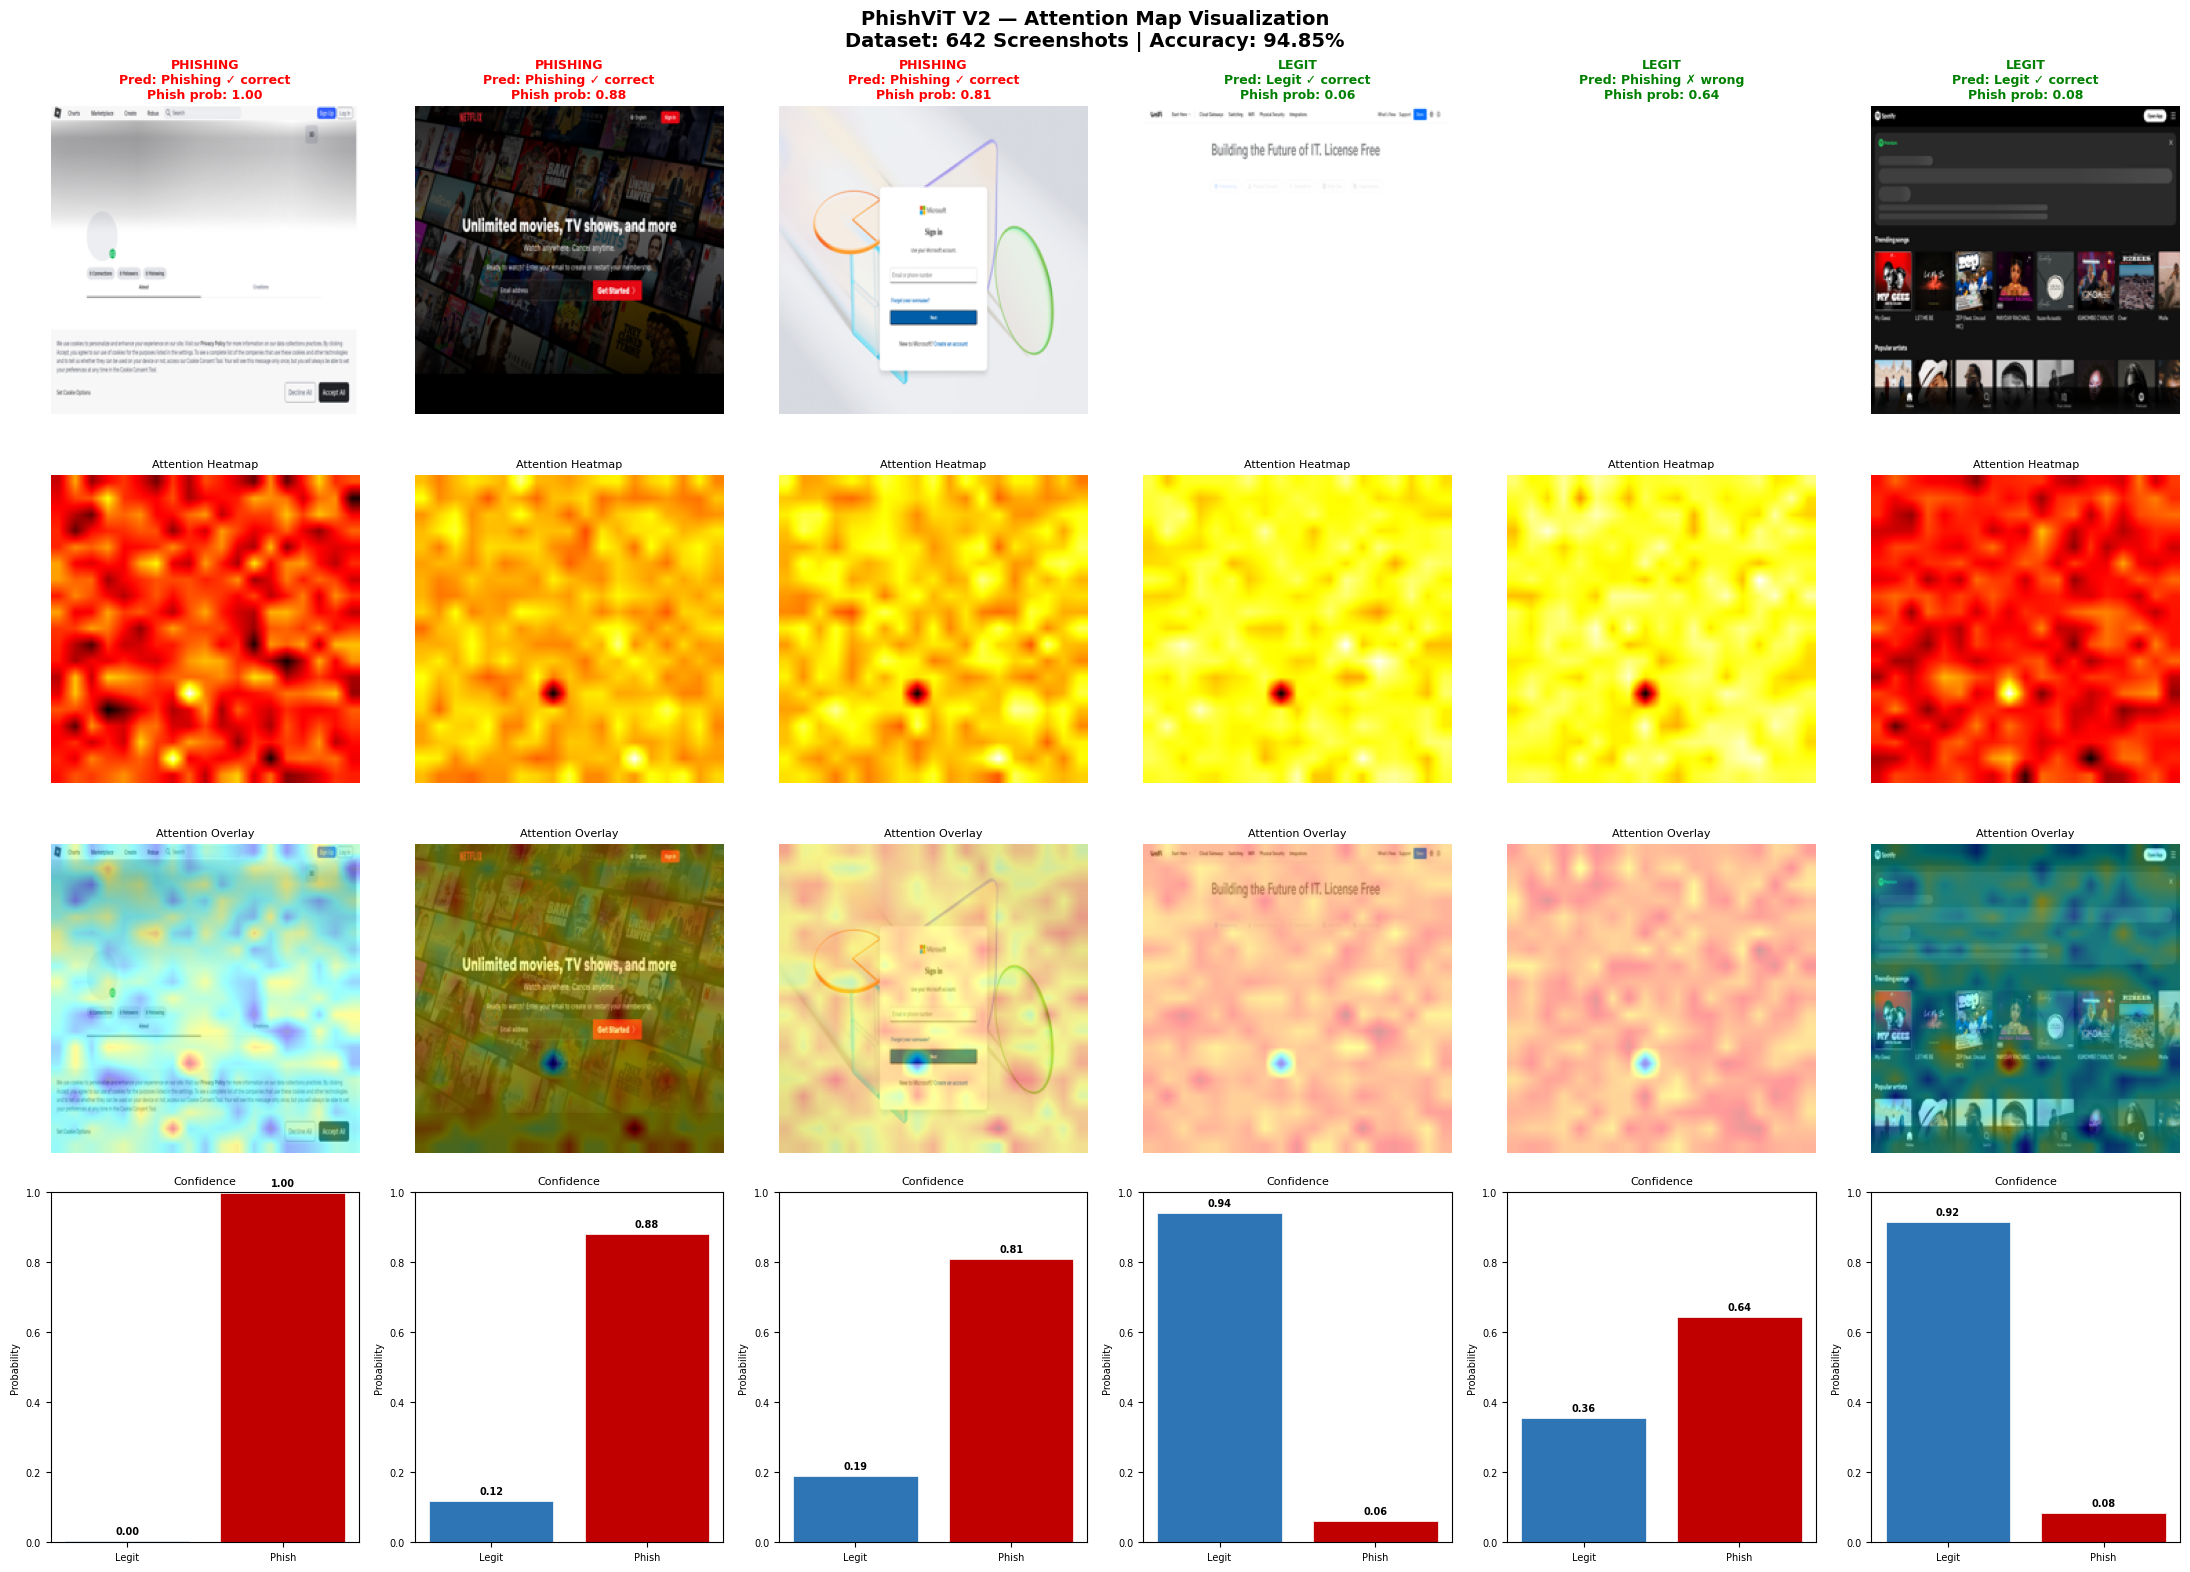

✅ Attention maps saved to Colab + Google Drive!


In [ ]:
# Attention Visualization V2
import cv2, numpy as np, math
from torchvision import transforms

def get_attention_map(model, img_tensor):
    attentions = []
    def hook_fn(module, input, output):
        attentions.append(output.detach().cpu())
    hooks = [block.attn.register_forward_hook(hook_fn) for block in model.blocks]
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(DEVICE))
    for hook in hooks:
        hook.remove()
    result = torch.eye(attentions[0].shape[-1])
    for attn in attentions:
        a = attn[0].mean(dim=0)
        a = a + torch.eye(a.shape[-1])
        a = a / a.sum(dim=-1, keepdim=True)
        result = torch.matmul(a, result)
    mask = result[0, 1:]
    w    = int(math.sqrt(mask.shape[0]))
    mask = mask[:w*w].reshape(w, w).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask

model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(4, 6, figsize=(22, 16))
fig.suptitle('PhishViT V2 — Attention Map Visualization\nDataset: 642 Screenshots | Accuracy: 94.85%',
             fontsize=14, fontweight='bold')

pidx = [i for i,l in enumerate(y_te) if l==1][:3]
lidx = [i for i,l in enumerate(y_te) if l==0][:3]

for col, (idx, tl) in enumerate(zip(pidx+lidx, [1,1,1,0,0,0])):
    img_pil    = Image.open(X_te[idx]).convert("RGB").resize((224,224))
    img_tensor = val_tf(img_pil)

    with torch.no_grad():
        out  = model(img_tensor.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(out, dim=1)[0,1].item()
        pred = out.argmax(1).item()

    try:
        am  = get_attention_map(model, img_tensor)
        am  = cv2.resize(am, (224,224))
        hm  = cv2.cvtColor(
                cv2.applyColorMap((am*255).astype(np.uint8), cv2.COLORMAP_JET),
                cv2.COLOR_BGR2RGB)
        ov  = cv2.addWeighted(np.array(img_pil), 0.6, hm, 0.4, 0)
    except:
        am  = np.zeros((224,224))
        ov  = np.array(img_pil)

    t = 'PHISHING' if tl==1   else 'LEGIT'
    p = 'Phishing' if pred==1 else 'Legit'
    k = '✓ correct' if pred==tl else '✗ wrong'
    c = 'red' if tl==1 else 'green'

    # Row 0 — Original screenshot
    axes[0,col].imshow(np.array(img_pil))
    axes[0,col].set_title(f'{t}\nPred: {p} {k}\nPhish prob: {prob:.2f}',
                           fontsize=9, color=c, fontweight='bold')
    axes[0,col].axis('off')

    # Row 1 — Raw attention heatmap
    axes[1,col].imshow(am, cmap='hot')
    axes[1,col].set_title('Attention Heatmap', fontsize=8)
    axes[1,col].axis('off')

    # Row 2 — Overlay on screenshot
    axes[2,col].imshow(ov)
    axes[2,col].set_title('Attention Overlay', fontsize=8)
    axes[2,col].axis('off')

    # Row 3 — Confidence bar chart
    axes[3,col].bar(['Legit','Phish'], [1-prob, prob],
                    color=['#2E75B6','#C00000'], edgecolor='white', linewidth=0.5)
    axes[3,col].set_ylim(0, 1)
    axes[3,col].set_title('Confidence', fontsize=8)
    axes[3,col].set_ylabel('Probability', fontsize=7)
    axes[3,col].tick_params(labelsize=7)
    for bar, val in zip(axes[3,col].patches, [1-prob, prob]):
        axes[3,col].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.02,
                         f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')

# Column headers
for col, title in enumerate(['Phishing 1','Phishing 2','Phishing 3',
                              'Legit 1',   'Legit 2',   'Legit 3']):
    axes[0,col].set_xlabel(title, fontsize=9, fontweight='bold')

plt.tight_layout()

# Save to Colab
plt.savefig('/content/phishvit/results/attention_maps/attention_v2.png',
            dpi=150, bbox_inches='tight')

# Save to Google Drive
import shutil
shutil.copy('/content/phishvit/results/attention_maps/attention_v2.png',
            '/content/drive/MyDrive/PhishViT/results_v2/attention_v2.png')

plt.show()
print("✅ Attention maps saved to Colab + Google Drive!")

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/PhishViT/results_v2/phishvit_v2_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>